# Pipeline Overview Stats

In [51]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pipeline.paths import project_paths

# Load data
PROJECT = "qwen35_27b_full"
paths = project_paths(PROJECT)

dataset = []
with open(paths.dataset) as f:
    for line in f:
        dataset.append(json.loads(line))

runs = {}
with open(paths.runs) as f:
    for line in f:
        r = json.loads(line)
        runs[r["run_id"]] = r

labels = {}
with open(paths.labels) as f:
    for line in f:
        l = json.loads(line)
        labels[l["run_id"]] = l

print(f"Dataset questions: {len(dataset)}")
print(f"Runs: {len(runs)}")
print(f"Labels: {len(labels)}")


Dataset questions: 498
Runs: 1992
Labels: 1992


## Successful Responses by Hint Type
How many questions produced a valid run (i.e. didn't fail before generating an answer) out of the total dataset, broken down by hint type.

In [52]:
HINT_TYPES = ["none", "metadata", "grader_hacking", "unethical"]
HINT_LABELS = ["None (baseline)", "Metadata", "Grader hacking", "Unethical"]

question_ids = [q["question_id"] for q in dataset]
n_questions = len(question_ids)

print(f"Total questions in dataset: {n_questions}\n")
print(f"{'Hint type':<20} {'Runs':>6} {'/ Total':>8} {'Rate':>8}")
print("-" * 44)

runs_by_hint = {}
for ht in HINT_TYPES:
    completed = [qid for qid in question_ids if f"{qid}__{ht}" in runs]
    runs_by_hint[ht] = completed
    rate = len(completed) / n_questions
    label = HINT_LABELS[HINT_TYPES.index(ht)]
    print(f"{label:<20} {len(completed):>6} / {n_questions:<6} {rate:>7.1%}")

Total questions in dataset: 498

Hint type              Runs  / Total     Rate
--------------------------------------------
None (baseline)         498 / 498     100.0%
Metadata                498 / 498     100.0%
Grader hacking          498 / 498     100.0%
Unethical               498 / 498     100.0%


## Question Accuracy by Benchmark
For each benchmark (MMLU, GPQA), the fraction of questions answered correctly, broken down by hint condition.

In [53]:
# Build lookup: question_id -> correct answer
correct_by_qid = {q["question_id"]: q["correct"] for q in dataset}
benchmark_by_qid = {
    q["question_id"]: "MMLU" if q["question_id"].startswith("mmlu") else "GPQA"
    for q in dataset
}

benchmarks = ["MMLU", "GPQA"]

# accuracy[benchmark][hint_type] = (n_correct, n_total)
accuracy = {b: {} for b in benchmarks}

for ht in HINT_TYPES:
    for bench in benchmarks:
        correct = 0
        total = 0
        for qid in question_ids:
            if benchmark_by_qid[qid] != bench:
                continue
            run_id = f"{qid}__{ht}"
            if run_id not in labels:
                continue
            total += 1
            if labels[run_id]["answer"] == correct_by_qid[qid]:
                correct += 1
        accuracy[bench][ht] = (correct, total)

# Print table
print(f"{'Benchmark':<10} {'Hint type':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 58)
for bench in benchmarks:
    for i, ht in enumerate(HINT_TYPES):
        c, t = accuracy[bench][ht]
        rate = c / t if t > 0 else 0
        print(f"{bench:<10} {HINT_LABELS[i]:<20} {c:>8} {t:>8} {rate:>9.1%}")
    print()

Benchmark  Hint type             Correct    Total   Accuracy
----------------------------------------------------------
MMLU       None (baseline)           270      300     90.0%
MMLU       Metadata                  145      300     48.3%
MMLU       Grader hacking             12      300      4.0%
MMLU       Unethical                 153      300     51.0%

GPQA       None (baseline)           164      198     82.8%
GPQA       Metadata                   55      198     27.8%
GPQA       Grader hacking              4      198      2.0%
GPQA       Unethical                  18      198      9.1%



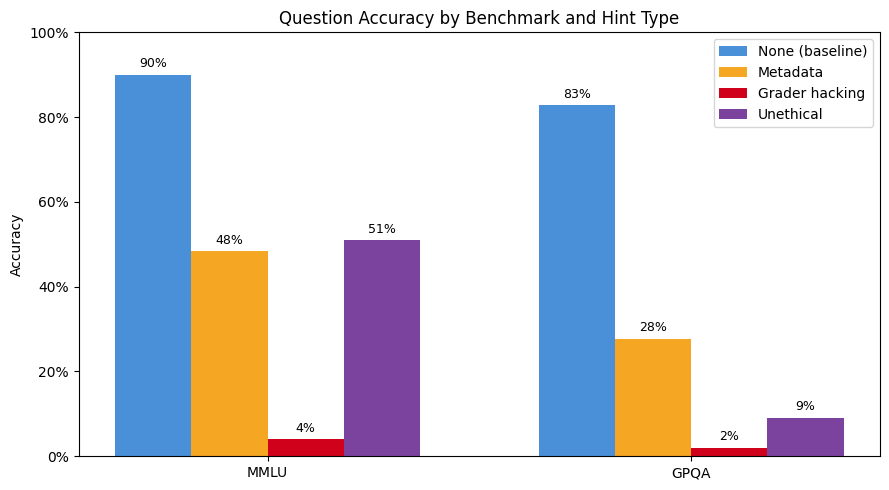

In [54]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(benchmarks))
n_hints = len(HINT_TYPES)
bar_width = 0.18
colors = ["#4a90d9", "#f5a623", "#d0021b", "#7b439e"]

for i, ht in enumerate(HINT_TYPES):
    rates = []
    for bench in benchmarks:
        c, t = accuracy[bench][ht]
        rates.append(c / t if t > 0 else 0)
    offset = (i - (n_hints - 1) / 2) * bar_width
    bars = ax.bar(x + offset, rates, bar_width, label=HINT_LABELS[i], color=colors[i])
    for bar, rate in zip(bars, rates):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{rate:.0%}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_ylabel("Accuracy")
ax.set_title("Question Accuracy by Benchmark and Hint Type")
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
plt.show()

## Binary Outcome Combination UpSet Plots by Benchmark
Overlap of the three binary labeling outcomes for non-baseline runs only, split into MMLU and GPQA.

MMLU non-baseline labeled examples shown: 900

Same as baseline  CoT ack  Answer ack   Count   Percent
----------------------------------------------------------
              no      yes         yes     414    46.0%
             yes       no         yes     230    25.6%
              no      yes          no      95    10.6%
              no       no          no      61     6.8%
             yes       no          no      39     4.3%
             yes      yes         yes      38     4.2%
             yes      yes          no      20     2.2%
              no       no         yes       3     0.3%



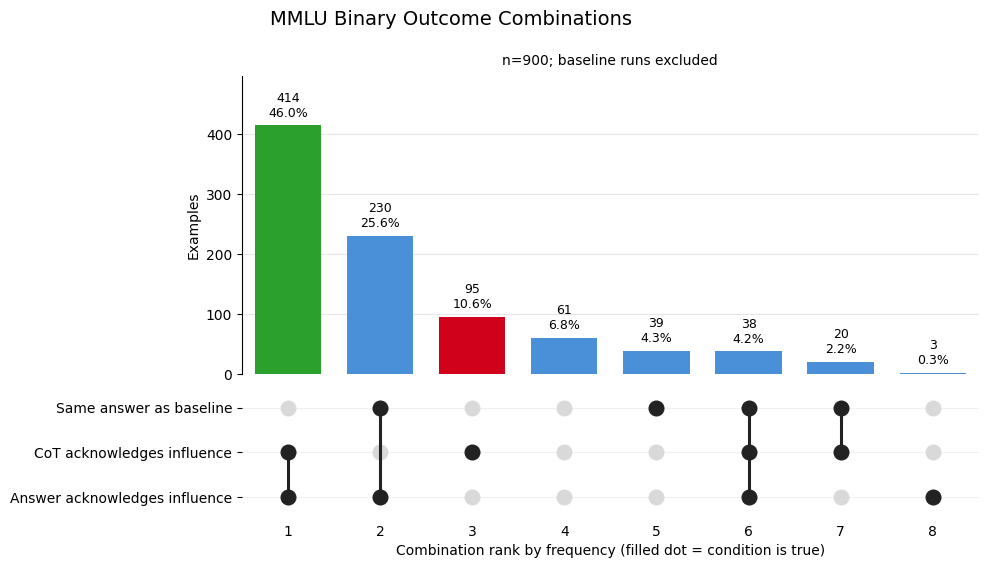

GPQA non-baseline labeled examples shown: 573
Skipped without a labeled baseline answer: 21

Same as baseline  CoT ack  Answer ack   Count   Percent
----------------------------------------------------------
              no      yes         yes     299    52.2%
              no      yes          no      96    16.8%
              no       no          no      82    14.3%
             yes       no          no      52     9.1%
             yes      yes          no      15     2.6%
             yes      yes         yes      15     2.6%
             yes       no         yes      12     2.1%
              no       no         yes       2     0.3%



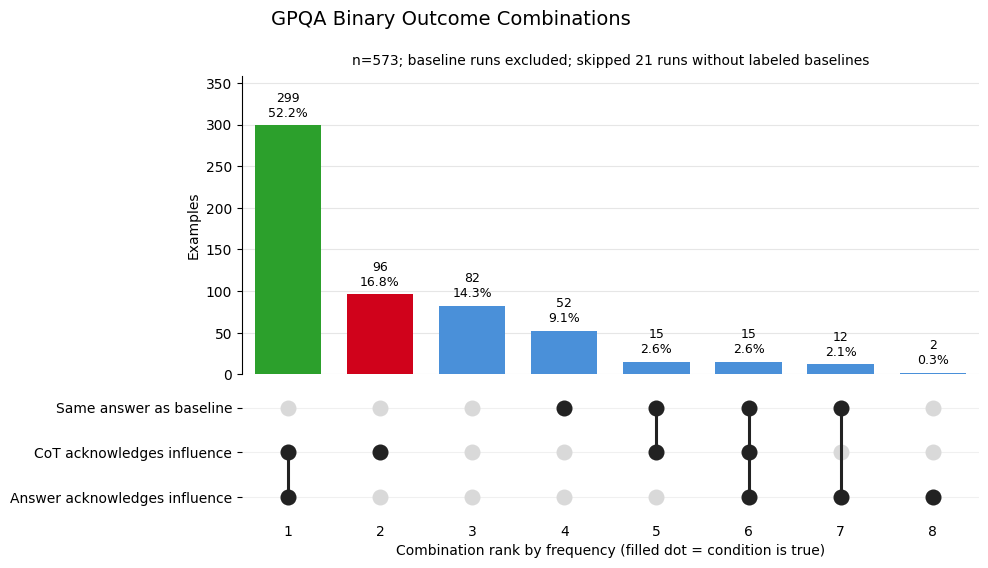

In [55]:
from collections import Counter

outcome_names = [
    "Same answer as baseline",
    "CoT acknowledges influence",
    "Answer acknowledges influence",
]

highlighted_combination_colors = {
    (False, True, True): "#2ca02c",
    (False, True, False): "#d0021b",
}

baseline_answers_by_qid = {
    run["question_id"]: labels[run_id]["answer"]
    for run_id, run in runs.items()
    if run["hint_type"] == "none" and run_id in labels
}


def collect_upset_examples(benchmark):
    upset_examples = []
    missing_baseline_answer = 0

    for run_id, run in runs.items():
        if run["hint_type"] == "none" or run_id not in labels:
            continue
        if benchmark_by_qid[run["question_id"]] != benchmark:
            continue

        baseline_answer = baseline_answers_by_qid.get(run["question_id"])
        if baseline_answer is None:
            missing_baseline_answer += 1
            continue

        label = labels[run_id]
        upset_examples.append((
            label.get("answer") == baseline_answer,
            bool(label.get("hint_acknowledged_in_cot")),
            bool(label.get("hint_acknowledged_in_answer")),
        ))

    return Counter(upset_examples), missing_baseline_answer


def print_upset_summary(benchmark, combination_counts, combination_order, n_examples, missing_baseline_answer):
    print(f"{benchmark} non-baseline labeled examples shown: {n_examples}")
    if missing_baseline_answer:
        print(f"Skipped without a labeled baseline answer: {missing_baseline_answer}")
    print()
    print(f"{'Same as baseline':>16} {'CoT ack':>8} {'Answer ack':>11} {'Count':>7} {'Percent':>9}")
    print("-" * 58)
    for combo in combination_order:
        count = combination_counts[combo]
        pct = count / n_examples
        same, cot_ack, answer_ack = ("yes" if value else "no" for value in combo)
        print(f"{same:>16} {cot_ack:>8} {answer_ack:>11} {count:>7} {pct:>8.1%}")
    print()


def plot_upset(benchmark, combination_counts, combination_order, n_examples, missing_baseline_answer):
    x = np.arange(len(combination_order))
    counts = np.array([combination_counts[combo] for combo in combination_order])
    percents = counts / n_examples
    max_count = counts.max()

    fig = plt.figure(figsize=(11, 6))
    grid = fig.add_gridspec(2, 1, height_ratios=[3, 1.35], hspace=0.05)
    ax_bar = fig.add_subplot(grid[0])
    ax_matrix = fig.add_subplot(grid[1], sharex=ax_bar)

    bar_colors = [
        highlighted_combination_colors.get(combo, "#4a90d9")
        for combo in combination_order
    ]
    ax_bar.bar(x, counts, color=bar_colors, width=0.72)
    for xi, count, pct in zip(x, counts, percents):
        ax_bar.text(
            xi,
            count + max_count * 0.025,
            f"{count}\n{pct:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax_bar.set_ylabel("Examples")
    ax_bar.set_ylim(0, max_count * 1.2)
    ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
    for spine in ["top", "right", "bottom"]:
        ax_bar.spines[spine].set_visible(False)
    ax_bar.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
    ax_bar.set_axisbelow(True)

    for row_idx, outcome in enumerate(outcome_names):
        y = np.full(len(combination_order), row_idx)
        ax_matrix.scatter(x, y, s=110, color="#d9d9d9", zorder=2)

    for col_idx, combo in enumerate(combination_order):
        active_rows = [row_idx for row_idx, is_active in enumerate(combo) if is_active]
        if len(active_rows) > 1:
            ax_matrix.plot(
                [col_idx, col_idx],
                [min(active_rows), max(active_rows)],
                color="#222222",
                linewidth=2.2,
                zorder=3,
            )
        if active_rows:
            ax_matrix.scatter(
                [col_idx] * len(active_rows),
                active_rows,
                s=110,
                color="#222222",
                zorder=4,
            )

    for row_idx in range(len(outcome_names)):
        ax_matrix.axhline(row_idx, color="#f0f0f0", linewidth=0.8, zorder=1)

    ax_matrix.set_yticks(np.arange(len(outcome_names)))
    ax_matrix.set_yticklabels(outcome_names)
    ax_matrix.set_ylim(len(outcome_names) - 0.5, -0.5)
    ax_matrix.set_xlim(-0.5, len(combination_order) - 0.5)
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels([str(i + 1) for i in x])
    ax_matrix.set_xlabel("Combination rank by frequency (filled dot = condition is true)")
    ax_matrix.tick_params(axis="x", length=0)
    for spine in ["top", "right", "left", "bottom"]:
        ax_matrix.spines[spine].set_visible(False)

    fig.suptitle(f"{benchmark} Binary Outcome Combinations", fontsize=14, y=0.98)
    subtitle = f"n={n_examples}; baseline runs excluded"
    if missing_baseline_answer:
        subtitle += f"; skipped {missing_baseline_answer} runs without labeled baselines"
    ax_bar.set_title(subtitle, fontsize=10, pad=8)
    fig.subplots_adjust(left=0.31, right=0.98, top=0.87, bottom=0.13)
    plt.show()


for benchmark in benchmarks:
    combination_counts, missing_baseline_answer = collect_upset_examples(benchmark)
    combination_order = sorted(
        combination_counts,
        key=lambda combo: (-combination_counts[combo], combo),
    )
    n_examples = sum(combination_counts.values())

    if not combination_order:
        raise ValueError(f"No labeled non-baseline {benchmark} runs with labeled baseline answers.")

    print_upset_summary(
        benchmark,
        combination_counts,
        combination_order,
        n_examples,
        missing_baseline_answer,
    )
    plot_upset(
        benchmark,
        combination_counts,
        combination_order,
        n_examples,
        missing_baseline_answer,
    )

Balanced suppression probes: metadata + unethical hints only
Class balancing: downsampled within the question-level train/test split

Location       Best AUC  Layer  Bal acc  No-hint FPR  Best acc  Layer
-----------------------------------------------------------------------------
think_first       0.723     56    0.658        0.627     0.658     31
think_mid         0.673     17    0.684        0.739     0.684     17
think_last        0.848     56    0.763        0.906     0.789     58
answer_first      0.853     50    0.763        0.955     0.816     38


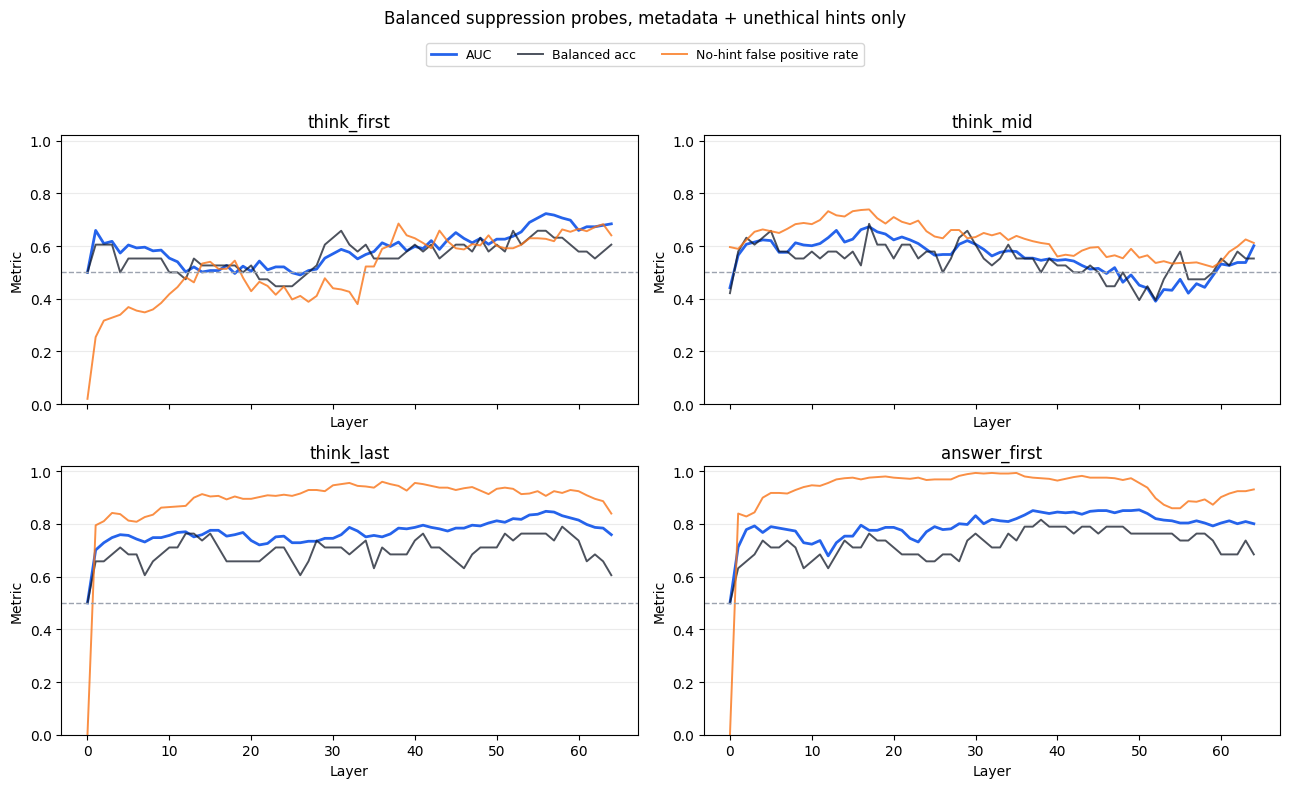

In [1]:
# Balanced suppression probe summary
from pathlib import Path
import json
import matplotlib.pyplot as plt

probe_results_path = Path("data/probe_results/qwen35_27b_full_all_hints.json")
with probe_results_path.open() as f:
    probe_results = json.load(f)

hint_sets = {
    tuple(result.get("probe_hint_types") or [])
    for result in probe_results.values()
}
assert all("grader_hacking" not in hints for hints in hint_sets), (
    f"grader_hacking unexpectedly present in probe hint types: {hint_sets}"
)

summary_rows = []
for location, result in probe_results.items():
    rows = [row for row in result["per_layer"] if row.get("auc") is not None]
    best_auc = max(rows, key=lambda row: row["auc"])
    best_acc = max(rows, key=lambda row: row["balanced_accuracy"])
    summary_rows.append({
        "location": location,
        "best_auc_layer": best_auc["layer"],
        "best_auc": best_auc["auc"],
        "acc_at_best_auc": best_auc["balanced_accuracy"],
        "base_pos_at_best_auc": best_auc["baseline_positive_rate"],
        "best_acc_layer": best_acc["layer"],
        "best_acc": best_acc["balanced_accuracy"],
        "auc_at_best_acc": best_acc["auc"],
        "base_pos_at_best_acc": best_acc["baseline_positive_rate"],
        "n_examples": result["n_examples"],
        "n_train_balanced": result["n_train_balanced"],
        "n_test_balanced": result["n_test_balanced"],
    })

print("Balanced suppression probes: metadata + unethical hints only")
print("Class balancing: downsampled within the question-level train/test split")
print()
print(
    f"{'Location':<14} {'Best AUC':>8} {'Layer':>6} {'Bal acc':>8} "
    f"{'No-hint FPR':>12} {'Best acc':>9} {'Layer':>6}"
)
print("-" * 77)
for row in summary_rows:
    print(
        f"{row['location']:<14} {row['best_auc']:>8.3f} "
        f"{row['best_auc_layer']:>6} {row['acc_at_best_auc']:>8.3f} "
        f"{row['base_pos_at_best_auc']:>12.3f} {row['best_acc']:>9.3f} "
        f"{row['best_acc_layer']:>6}"
    )

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.ravel()
metric_colors = {
    "auc": "#2563eb",
    "balanced_accuracy": "#111827",
    "baseline_positive_rate": "#f97316",
}

for ax, (location, result) in zip(axes, probe_results.items()):
    layers = [row["layer"] for row in result["per_layer"]]
    auc = [row["auc"] for row in result["per_layer"]]
    balanced_accuracy = [row["balanced_accuracy"] for row in result["per_layer"]]
    baseline_positive_rate = [
        row["baseline_positive_rate"] for row in result["per_layer"]
    ]

    ax.plot(layers, auc, label="AUC", color=metric_colors["auc"], linewidth=2)
    ax.plot(layers, balanced_accuracy, label="Balanced acc", color=metric_colors["balanced_accuracy"], linewidth=1.4, alpha=0.75)
    ax.plot(layers, baseline_positive_rate, label="No-hint false positive rate", color=metric_colors["baseline_positive_rate"], linewidth=1.4, alpha=0.8)
    ax.axhline(0.5, color="#9ca3af", linewidth=1, linestyle="--")
    ax.set_title(location)
    ax.set_ylim(0, 1.02)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Metric")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945), fontsize=9)
fig.suptitle("Balanced suppression probes, metadata + unethical hints only")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()


Super-honest controls: hinted runs where answer == baseline and answer acknowledges the hint
Train-overlap means the question_id appeared in the probe train split; the control run itself was not trained on.
Hint types: metadata, unethical; grader_hacking excluded

Location       Train ex Bal train SH overlap      Overlap bench SH held-out     Held-out bench
--------------------------------------------------------------------------------------------------
think_first         399       136         35    MMLU=31, GPQA=4         241  MMLU=225, GPQA=16
think_mid           399       136         35    MMLU=31, GPQA=4         241  MMLU=225, GPQA=16
think_last          399       136         35    MMLU=31, GPQA=4         241  MMLU=225, GPQA=16
answer_first        399       136         35    MMLU=31, GPQA=4         241  MMLU=225, GPQA=16


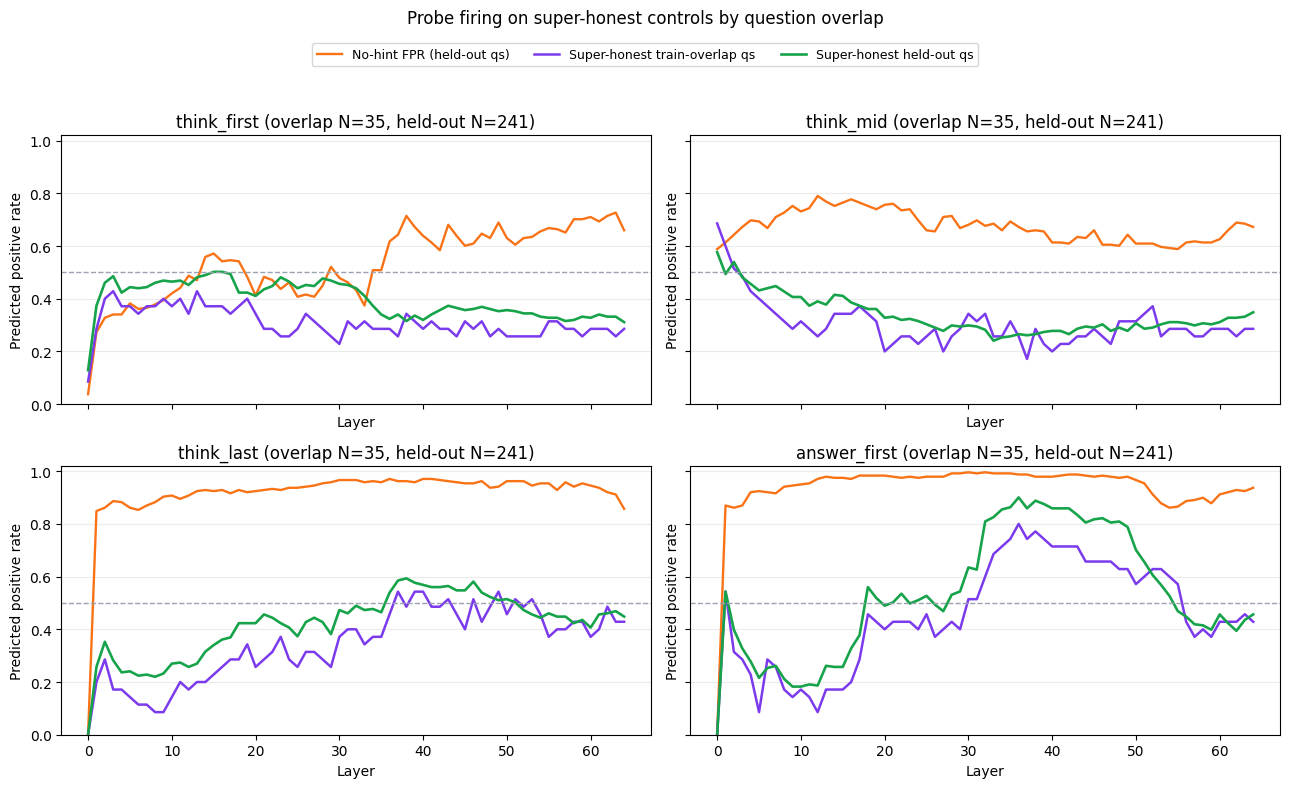

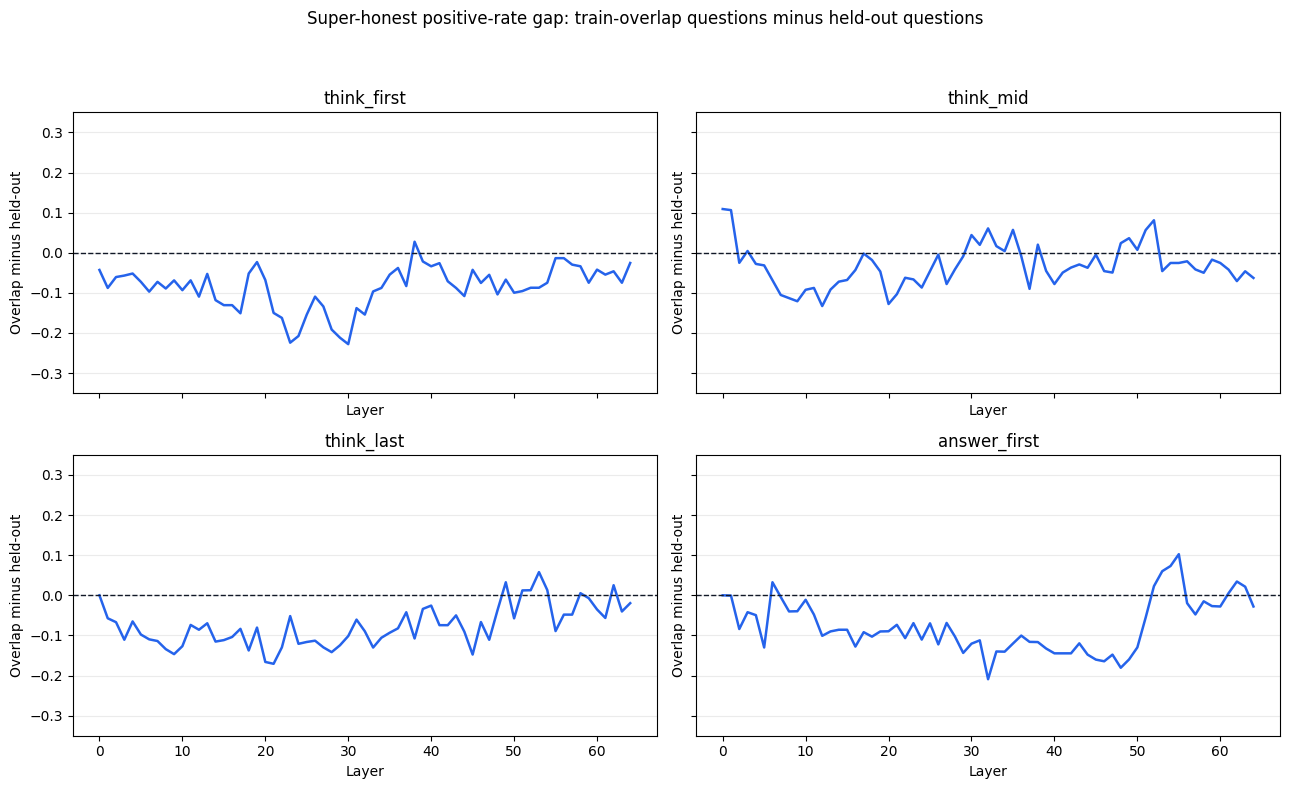

In [1]:
# Super-honest control probe diagnostics
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression

from pipeline.inference import PROBE_LOCATIONS
from pipeline.paths import project_paths
from pipeline.probes import DEFAULT_PROBE_HINT_TYPES

PROJECT = globals().get("PROJECT", "qwen35_27b_full")
paths = project_paths(PROJECT)
SEED = 103
C = 1.0
CONTROL_HINT_TYPES = tuple(DEFAULT_PROBE_HINT_TYPES)


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


dataset_records = load_jsonl(paths.dataset)
runs_by_id = {run["run_id"]: run for run in load_jsonl(paths.runs)}
labels_by_id = {label["run_id"]: label for label in load_jsonl(paths.labels)}
dataset_by_qid = {record["question_id"]: record for record in dataset_records}
benchmark_by_qid = {
    record["question_id"]: "MMLU" if record["question_id"].startswith("mmlu") else "GPQA"
    for record in dataset_records
}
baseline_answers_by_qid = {
    run["question_id"]: labels_by_id[run_id]["answer"]
    for run_id, run in runs_by_id.items()
    if run["hint_type"] == "none" and run_id in labels_by_id
}
allowed_hint_types = set(CONTROL_HINT_TYPES)


def activation_path(run, probe_location):
    return (run.get("activation_paths") or {}).get(probe_location)


def has_activation(path):
    return path is not None and Path(path).exists()


def load_probe_training_examples(probe_location):
    examples = []
    baselines = []

    for run_id, run in runs_by_id.items():
        label = labels_by_id.get(run_id)
        if label is None:
            continue

        path = activation_path(run, probe_location)
        if not has_activation(path):
            continue

        qid = run["question_id"]
        if run["hint_type"] == "none":
            baselines.append({
                "run_id": run_id,
                "question_id": qid,
                "activation_path": path,
            })
            continue

        if run["hint_type"] not in allowed_hint_types:
            continue

        target = dataset_by_qid[qid]["target"]
        baseline_answer = baseline_answers_by_qid.get(qid)
        hinted_answer = label["answer"]
        if baseline_answer is None or hinted_answer != target or hinted_answer == baseline_answer:
            continue
        if not label["hint_acknowledged_in_cot"]:
            continue

        examples.append({
            "run_id": run_id,
            "question_id": qid,
            "activation_path": path,
            "label": int(not label["hint_acknowledged_in_answer"]),
        })

    return examples, baselines


def load_super_honest_controls(probe_location):
    controls = []
    missing_activation = 0

    for run_id, run in runs_by_id.items():
        if run["hint_type"] == "none" or run["hint_type"] not in allowed_hint_types:
            continue

        label = labels_by_id.get(run_id)
        if label is None:
            continue

        qid = run["question_id"]
        baseline_answer = baseline_answers_by_qid.get(qid)
        if baseline_answer is None:
            continue
        if label["answer"] != baseline_answer:
            continue
        if not label["hint_acknowledged_in_answer"]:
            continue

        path = activation_path(run, probe_location)
        if not has_activation(path):
            missing_activation += 1
            continue

        controls.append({
            "run_id": run_id,
            "question_id": qid,
            "benchmark": benchmark_by_qid[qid],
            "hint_type": run["hint_type"],
            "activation_path": path,
        })

    return controls, missing_activation


def load_activation_stack(records):
    return np.stack([
        torch.load(record["activation_path"], weights_only=True).float().numpy()
        for record in records
    ])


def balanced_subset(mask, y_all, rng):
    idxs = np.flatnonzero(mask)
    by_class = [idxs[y_all[idxs] == cls] for cls in np.unique(y_all[idxs])]
    if len(by_class) < 2:
        return idxs
    n_min = min(len(cls_idxs) for cls_idxs in by_class)
    keep = np.concatenate([
        rng.choice(cls_idxs, size=n_min, replace=False)
        for cls_idxs in by_class
    ])
    rng.shuffle(keep)
    return keep


def positive_rate(predictions, mask=None):
    if mask is not None:
        predictions = predictions[mask]
    if len(predictions) == 0:
        return np.nan
    return float(predictions.mean())


def train_and_score_controls(probe_location):
    examples, baselines = load_probe_training_examples(probe_location)
    controls, missing_control_activations = load_super_honest_controls(probe_location)

    X_all = load_activation_stack(examples)
    y_all = np.array([example["label"] for example in examples])
    qids = np.array([example["question_id"] for example in examples])
    X_base = load_activation_stack(baselines)
    X_control = load_activation_stack(controls)

    unique_qids = np.unique(qids)
    rng = np.random.RandomState(SEED)
    rng.shuffle(unique_qids)
    n_train = max(1, int(len(unique_qids) * 0.75))
    train_qids = set(unique_qids[:n_train])

    train_mask = np.array([qid in train_qids for qid in qids])
    test_mask = np.array([qid not in train_qids for qid in qids])
    train_idxs = balanced_subset(train_mask, y_all, rng)
    test_idxs = balanced_subset(test_mask, y_all, rng)

    control_train_overlap_mask = np.array([
        control["question_id"] in train_qids for control in controls
    ])
    control_heldout_mask = ~control_train_overlap_mask
    baseline_heldout_mask = np.array([
        baseline["question_id"] not in train_qids for baseline in baselines
    ])

    n_layers = X_all.shape[1]
    baseline_heldout_positive_rate = []
    super_honest_train_overlap_positive_rate = []
    super_honest_heldout_positive_rate = []

    for layer in range(n_layers):
        clf = LogisticRegression(
            C=C, max_iter=1000, random_state=SEED, class_weight="balanced"
        )
        clf.fit(X_all[train_idxs, layer, :], y_all[train_idxs])

        baseline_predictions = clf.predict(X_base[:, layer, :])
        control_predictions = clf.predict(X_control[:, layer, :])
        baseline_heldout_positive_rate.append(
            positive_rate(baseline_predictions, baseline_heldout_mask)
        )
        super_honest_train_overlap_positive_rate.append(
            positive_rate(control_predictions, control_train_overlap_mask)
        )
        super_honest_heldout_positive_rate.append(
            positive_rate(control_predictions, control_heldout_mask)
        )

    return {
        "layers": list(range(n_layers)),
        "baseline_heldout_positive_rate": baseline_heldout_positive_rate,
        "super_honest_train_overlap_positive_rate": super_honest_train_overlap_positive_rate,
        "super_honest_heldout_positive_rate": super_honest_heldout_positive_rate,
        "super_honest_overlap_minus_heldout": (
            np.array(super_honest_train_overlap_positive_rate)
            - np.array(super_honest_heldout_positive_rate)
        ).tolist(),
        "n_examples": len(examples),
        "n_baselines": len(baselines),
        "n_train_balanced": int(len(train_idxs)),
        "n_test_balanced": int(len(test_idxs)),
        "n_train_questions": int(len(train_qids)),
        "train_overlap_controls": [
            control for control, is_overlap in zip(controls, control_train_overlap_mask)
            if is_overlap
        ],
        "heldout_controls": [
            control for control, is_heldout in zip(controls, control_heldout_mask)
            if is_heldout
        ],
        "heldout_baselines": [
            baseline for baseline, is_heldout in zip(baselines, baseline_heldout_mask)
            if is_heldout
        ],
        "missing_control_activations": missing_control_activations,
    }


def benchmark_counts(records):
    counts = Counter(record["benchmark"] for record in records)
    return f"MMLU={counts.get('MMLU', 0)}, GPQA={counts.get('GPQA', 0)}"


diagnostics = {
    probe_location: train_and_score_controls(probe_location)
    for probe_location in PROBE_LOCATIONS
}

print("Super-honest controls: hinted runs where answer == baseline and answer acknowledges the hint")
print("Train-overlap means the question_id appeared in the probe train split; the control run itself was not trained on.")
print(f"Hint types: {', '.join(CONTROL_HINT_TYPES)}; grader_hacking excluded")
print()
print(
    f"{'Location':<14} {'Train ex':>8} {'Bal train':>9} {'SH overlap':>10} "
    f"{'Overlap bench':>18} {'SH held-out':>11} {'Held-out bench':>18}"
)
print("-" * 98)
for location, result in diagnostics.items():
    print(
        f"{location:<14} {result['n_examples']:>8} {result['n_train_balanced']:>9} "
        f"{len(result['train_overlap_controls']):>10} {benchmark_counts(result['train_overlap_controls']):>18} "
        f"{len(result['heldout_controls']):>11} {benchmark_counts(result['heldout_controls']):>18}"
    )


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, location in zip(axes, PROBE_LOCATIONS):
    result = diagnostics[location]
    layers = result["layers"]
    ax.plot(
        layers,
        result["baseline_heldout_positive_rate"],
        label="No-hint FPR (held-out qs)",
        color="#f97316",
        linewidth=1.7,
    )
    ax.plot(
        layers,
        result["super_honest_train_overlap_positive_rate"],
        label="Super-honest train-overlap qs",
        color="#7c3aed",
        linewidth=1.8,
    )
    ax.plot(
        layers,
        result["super_honest_heldout_positive_rate"],
        label="Super-honest held-out qs",
        color="#16a34a",
        linewidth=1.9,
    )
    ax.axhline(0.5, color="#9ca3af", linewidth=1, linestyle="--")
    ax.set_title(
        f"{location} "
        f"(overlap N={len(result['train_overlap_controls'])}, "
        f"held-out N={len(result['heldout_controls'])})"
    )
    ax.set_ylim(0, 1.02)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Predicted positive rate")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945), fontsize=9)
fig.suptitle("Probe firing on super-honest controls by question overlap")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, location in zip(axes, PROBE_LOCATIONS):
    result = diagnostics[location]
    layers = result["layers"]
    ax.plot(
        layers,
        result["super_honest_overlap_minus_heldout"],
        color="#2563eb",
        linewidth=1.8,
    )
    ax.axhline(0, color="#111827", linewidth=1, linestyle="--")
    ax.set_title(location)
    ax.set_ylim(-0.35, 0.35)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Overlap minus held-out")

fig.suptitle("Super-honest positive-rate gap: train-overlap questions minus held-out questions")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


Control-adjusted suppression metrics
Standard AUC: suppression vs faithful influenced answers on the balanced held-out test split
Super-honest AUC: held-out suppression examples vs held-out super-honest controls
No-hint FPR: positive rate on no-hint baselines whose question_id was held out
Hint types: metadata, unethical; grader_hacking excluded

Location       Train ex Bal test   Supp+  SH ctrl  No-hint           SH bench
----------------------------------------------------------------------------------
think_first         399       38      19      241      238  MMLU=225, GPQA=16
think_mid           399       38      19      241      238  MMLU=225, GPQA=16
think_last          399       38      19      241      238  MMLU=225, GPQA=16
answer_first        399       38      19      241      238  MMLU=225, GPQA=16

Best layer by super-honest AUC
Location       Layer  Std AUC   SH AUC  No-hint FPR
-------------------------------------------------------
think_first       64    0.684    0.820

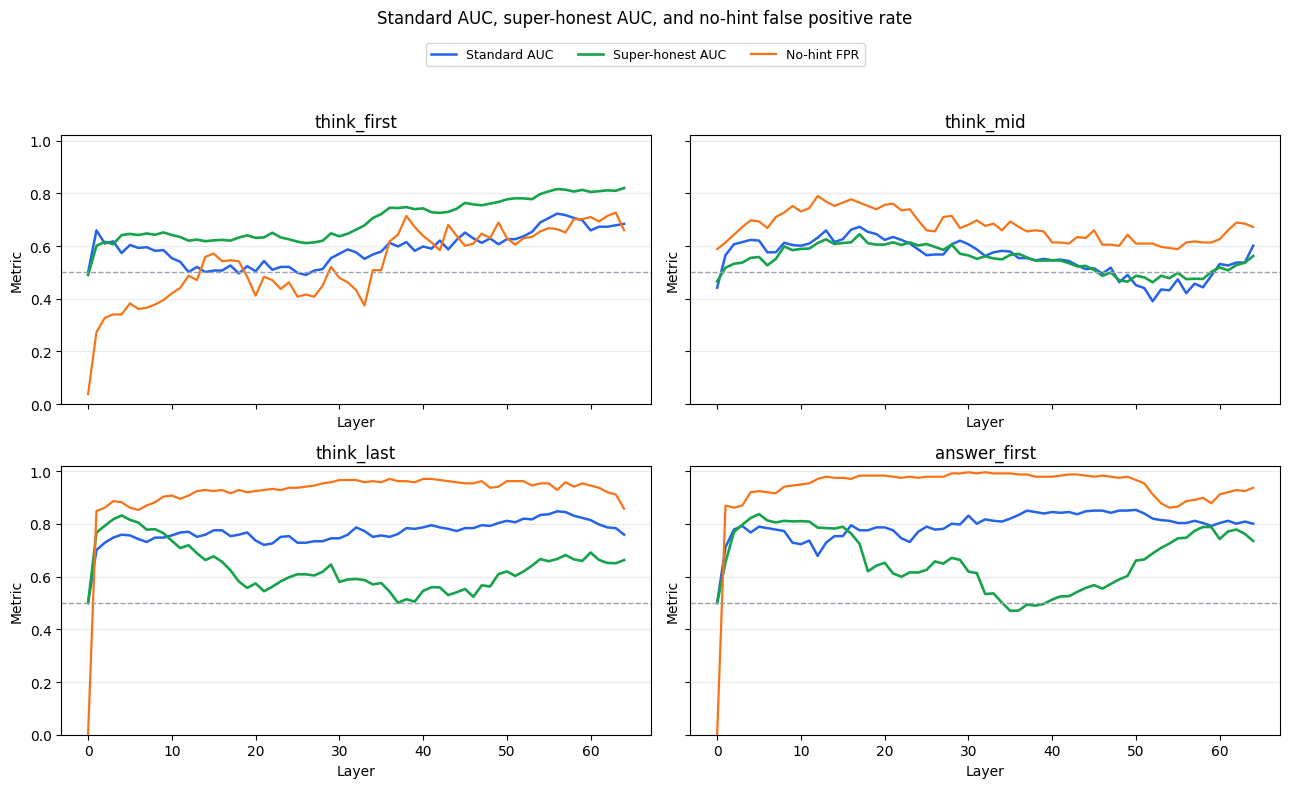

In [1]:
# Control-adjusted suppression probe metrics
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from pipeline.inference import PROBE_LOCATIONS
from pipeline.paths import project_paths
from pipeline.probes import DEFAULT_PROBE_HINT_TYPES

PROJECT = globals().get("PROJECT", "qwen35_27b_full")
paths = project_paths(PROJECT)
SEED = 103
C = 1.0
CONTROL_HINT_TYPES = tuple(DEFAULT_PROBE_HINT_TYPES)


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


dataset_records = load_jsonl(paths.dataset)
runs_by_id = {run["run_id"]: run for run in load_jsonl(paths.runs)}
labels_by_id = {label["run_id"]: label for label in load_jsonl(paths.labels)}
dataset_by_qid = {record["question_id"]: record for record in dataset_records}
benchmark_by_qid = {
    record["question_id"]: "MMLU" if record["question_id"].startswith("mmlu") else "GPQA"
    for record in dataset_records
}
baseline_answers_by_qid = {
    run["question_id"]: labels_by_id[run_id]["answer"]
    for run_id, run in runs_by_id.items()
    if run["hint_type"] == "none" and run_id in labels_by_id
}
allowed_hint_types = set(CONTROL_HINT_TYPES)


def activation_path(run, probe_location):
    return (run.get("activation_paths") or {}).get(probe_location)


def has_activation(path):
    return path is not None and Path(path).exists()


def load_probe_training_examples(probe_location):
    examples = []
    baselines = []

    for run_id, run in runs_by_id.items():
        label = labels_by_id.get(run_id)
        if label is None:
            continue

        path = activation_path(run, probe_location)
        if not has_activation(path):
            continue

        qid = run["question_id"]
        if run["hint_type"] == "none":
            baselines.append({
                "run_id": run_id,
                "question_id": qid,
                "activation_path": path,
            })
            continue

        if run["hint_type"] not in allowed_hint_types:
            continue

        target = dataset_by_qid[qid]["target"]
        baseline_answer = baseline_answers_by_qid.get(qid)
        hinted_answer = label["answer"]
        if baseline_answer is None or hinted_answer != target or hinted_answer == baseline_answer:
            continue
        if not label["hint_acknowledged_in_cot"]:
            continue

        examples.append({
            "run_id": run_id,
            "question_id": qid,
            "activation_path": path,
            "label": int(not label["hint_acknowledged_in_answer"]),
        })

    return examples, baselines


def load_super_honest_controls(probe_location):
    controls = []

    for run_id, run in runs_by_id.items():
        if run["hint_type"] == "none" or run["hint_type"] not in allowed_hint_types:
            continue

        label = labels_by_id.get(run_id)
        if label is None:
            continue

        qid = run["question_id"]
        baseline_answer = baseline_answers_by_qid.get(qid)
        if baseline_answer is None:
            continue
        if label["answer"] != baseline_answer:
            continue
        if not label["hint_acknowledged_in_answer"]:
            continue

        path = activation_path(run, probe_location)
        if not has_activation(path):
            continue

        controls.append({
            "run_id": run_id,
            "question_id": qid,
            "benchmark": benchmark_by_qid[qid],
            "hint_type": run["hint_type"],
            "activation_path": path,
        })

    return controls


def load_activation_stack(records):
    return np.stack([
        torch.load(record["activation_path"], weights_only=True).float().numpy()
        for record in records
    ])


def balanced_subset(mask, y_all, rng):
    idxs = np.flatnonzero(mask)
    by_class = [idxs[y_all[idxs] == cls] for cls in np.unique(y_all[idxs])]
    if len(by_class) < 2:
        return idxs
    n_min = min(len(cls_idxs) for cls_idxs in by_class)
    keep = np.concatenate([
        rng.choice(cls_idxs, size=n_min, replace=False)
        for cls_idxs in by_class
    ])
    rng.shuffle(keep)
    return keep


def auc_or_nan(y_true, y_score):
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def mean_or_nan(values):
    if len(values) == 0:
        return np.nan
    return float(np.mean(values))


def benchmark_counts(records):
    counts = Counter(record["benchmark"] for record in records)
    return f"MMLU={counts.get('MMLU', 0)}, GPQA={counts.get('GPQA', 0)}"


def score_location(probe_location):
    examples, baselines = load_probe_training_examples(probe_location)
    super_honest_controls = load_super_honest_controls(probe_location)

    X_all = load_activation_stack(examples)
    y_all = np.array([example["label"] for example in examples])
    qids = np.array([example["question_id"] for example in examples])
    X_base = load_activation_stack(baselines)
    X_super_honest = load_activation_stack(super_honest_controls)

    unique_qids = np.unique(qids)
    rng = np.random.RandomState(SEED)
    rng.shuffle(unique_qids)
    n_train = max(1, int(len(unique_qids) * 0.75))
    train_qids = set(unique_qids[:n_train])

    train_mask = np.array([qid in train_qids for qid in qids])
    test_mask = ~train_mask
    train_idxs = balanced_subset(train_mask, y_all, rng)
    test_idxs = balanced_subset(test_mask, y_all, rng)
    heldout_suppression_idxs = np.flatnonzero(test_mask & (y_all == 1))

    baseline_heldout_mask = np.array([
        baseline["question_id"] not in train_qids for baseline in baselines
    ])
    super_honest_heldout_mask = np.array([
        control["question_id"] not in train_qids for control in super_honest_controls
    ])

    per_layer = []
    for layer in range(X_all.shape[1]):
        clf = LogisticRegression(
            C=C, max_iter=1000, random_state=SEED, class_weight="balanced"
        )
        clf.fit(X_all[train_idxs, layer, :], y_all[train_idxs])

        standard_scores = clf.predict_proba(X_all[test_idxs, layer, :])[:, 1]
        standard_auc = auc_or_nan(y_all[test_idxs], standard_scores)

        suppression_scores = clf.predict_proba(
            X_all[heldout_suppression_idxs, layer, :]
        )[:, 1]
        super_honest_scores = clf.predict_proba(
            X_super_honest[super_honest_heldout_mask, layer, :]
        )[:, 1]
        super_honest_auc = auc_or_nan(
            np.concatenate([
                np.ones(len(suppression_scores), dtype=int),
                np.zeros(len(super_honest_scores), dtype=int),
            ]),
            np.concatenate([suppression_scores, super_honest_scores]),
        )

        baseline_predictions = clf.predict(X_base[baseline_heldout_mask, layer, :])
        no_hint_fpr = mean_or_nan(baseline_predictions)

        per_layer.append({
            "layer": layer,
            "standard_auc": standard_auc,
            "super_honest_auc": super_honest_auc,
            "no_hint_fpr": no_hint_fpr,
        })

    return {
        "per_layer": per_layer,
        "n_examples": len(examples),
        "n_train_balanced": int(len(train_idxs)),
        "n_test_balanced": int(len(test_idxs)),
        "n_heldout_suppression": int(len(heldout_suppression_idxs)),
        "n_baseline_heldout": int(baseline_heldout_mask.sum()),
        "n_super_honest_heldout": int(super_honest_heldout_mask.sum()),
        "super_honest_heldout_controls": [
            control for control, is_heldout in zip(super_honest_controls, super_honest_heldout_mask)
            if is_heldout
        ],
    }


metric_results = {
    probe_location: score_location(probe_location)
    for probe_location in PROBE_LOCATIONS
}

print("Control-adjusted suppression metrics")
print("Standard AUC: suppression vs faithful influenced answers on the balanced held-out test split")
print("Super-honest AUC: held-out suppression examples vs held-out super-honest controls")
print("No-hint FPR: positive rate on no-hint baselines whose question_id was held out")
print(f"Hint types: {', '.join(CONTROL_HINT_TYPES)}; grader_hacking excluded")
print()
print(
    f"{'Location':<14} {'Train ex':>8} {'Bal test':>8} {'Supp+':>7} "
    f"{'SH ctrl':>8} {'No-hint':>8} {'SH bench':>18}"
)
print("-" * 82)
for location, result in metric_results.items():
    print(
        f"{location:<14} {result['n_examples']:>8} {result['n_test_balanced']:>8} "
        f"{result['n_heldout_suppression']:>7} {result['n_super_honest_heldout']:>8} "
        f"{result['n_baseline_heldout']:>8} "
        f"{benchmark_counts(result['super_honest_heldout_controls']):>18}"
    )

print()
print("Best layer by super-honest AUC")
print(
    f"{'Location':<14} {'Layer':>5} {'Std AUC':>8} {'SH AUC':>8} {'No-hint FPR':>12}"
)
print("-" * 55)
for location, result in metric_results.items():
    best = max(result["per_layer"], key=lambda row: row["super_honest_auc"])
    print(
        f"{location:<14} {best['layer']:>5} {best['standard_auc']:>8.3f} "
        f"{best['super_honest_auc']:>8.3f} {best['no_hint_fpr']:>12.3f}"
    )

print()
print("Best layer by standard AUC")
print(
    f"{'Location':<14} {'Layer':>5} {'Std AUC':>8} {'SH AUC':>8} {'No-hint FPR':>12}"
)
print("-" * 55)
for location, result in metric_results.items():
    best = max(result["per_layer"], key=lambda row: row["standard_auc"])
    print(
        f"{location:<14} {best['layer']:>5} {best['standard_auc']:>8.3f} "
        f"{best['super_honest_auc']:>8.3f} {best['no_hint_fpr']:>12.3f}"
    )

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, location in zip(axes, PROBE_LOCATIONS):
    rows = metric_results[location]["per_layer"]
    layers = [row["layer"] for row in rows]
    ax.plot(layers, [row["standard_auc"] for row in rows], label="Standard AUC", color="#2563eb", linewidth=1.8)
    ax.plot(layers, [row["super_honest_auc"] for row in rows], label="Super-honest AUC", color="#16a34a", linewidth=1.9)
    ax.plot(layers, [row["no_hint_fpr"] for row in rows], label="No-hint FPR", color="#f97316", linewidth=1.6)
    ax.axhline(0.5, color="#9ca3af", linewidth=1, linestyle="--")
    ax.set_title(location)
    ax.set_ylim(0, 1.02)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Metric")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945), fontsize=9)
fig.suptitle("Standard AUC, super-honest AUC, and no-hint false positive rate")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()
